In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv("test.csv")

In [64]:
train.rename(columns={'SalePrice': 'Price'})

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,Price
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


<Axes: >

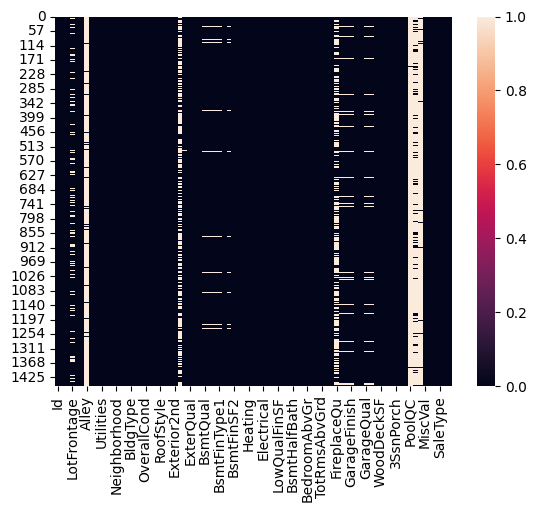

In [4]:
# Check for NAs
sns.heatmap(train.isna())

### Choose relevant features

In [5]:
subset = ["SalePrice", "YrSold", "GarageArea", "KitchenQual", "YearBuilt", "OverallQual", "LotArea", "GrLivArea"]

train1 = train[subset]
test1 = test[subset[1:]]

In [6]:
train1

,SalePrice,YrSold,GarageArea,KitchenQual,YearBuilt,OverallQual,LotArea,GrLivArea
0,208500,2008,548,Gd,2003,7,8450,1710
1,181500,2007,460,TA,1976,6,9600,1262
2,223500,2008,608,Gd,2001,7,11250,1786
3,140000,2006,642,Gd,1915,7,9550,1717
4,250000,2008,836,Gd,2000,8,14260,2198
...,...,...,...,...,...,...,...,...
1455,175000,2007,460,TA,1999,6,7917,1647
1456,210000,2010,500,TA,1978,6,13175,2073
1457,266500,2010,252,Gd,1941,7,9042,2340
1458,142125,2010,240,Gd,1950,5,9717,1078


In [7]:
train_dummies = pd.get_dummies(train1["KitchenQual"], "Kitchen", dtype = int).drop("Kitchen_Fa", axis=1)
test_dummies = pd.get_dummies(test1["KitchenQual"], "Kitchen", dtype = int).drop("Kitchen_Fa", axis=1)

In [8]:
train1 = pd.concat([train1.drop("KitchenQual", axis=1), train_dummies], axis=1)
test1 = pd.concat([test1.drop("KitchenQual", axis=1), test_dummies], axis=1)

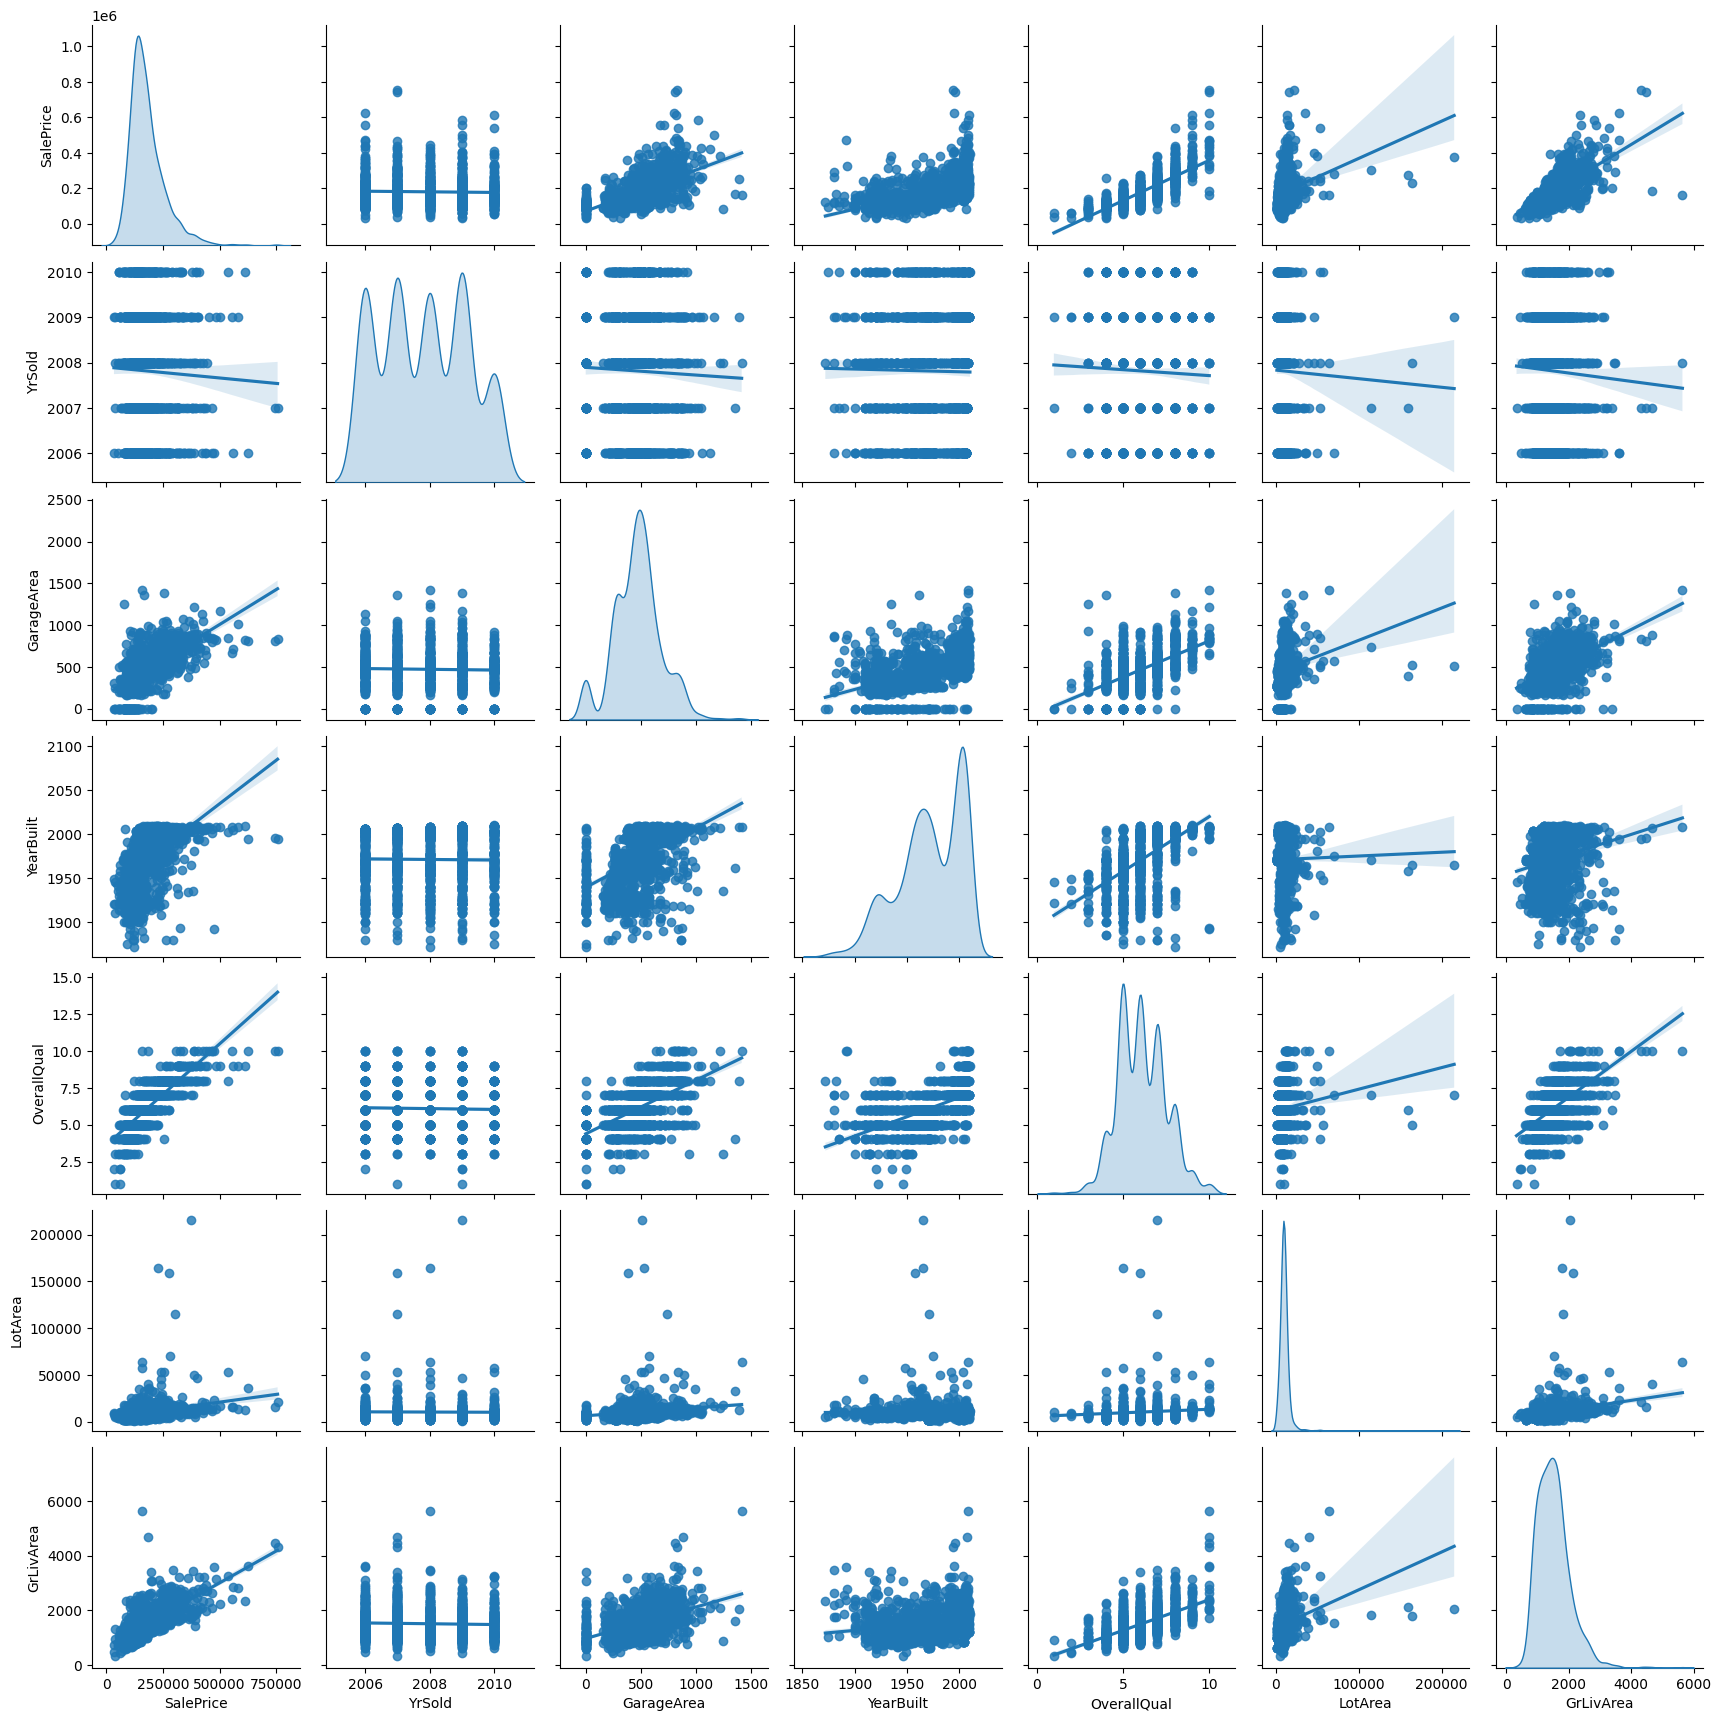

In [9]:
# EDA
sns.pairplot(train1.drop(train_dummies.columns.to_list(), axis=1), kind="reg", diag_kind="kde")

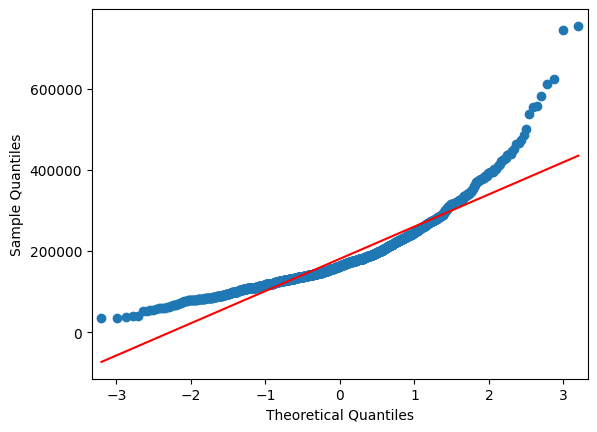

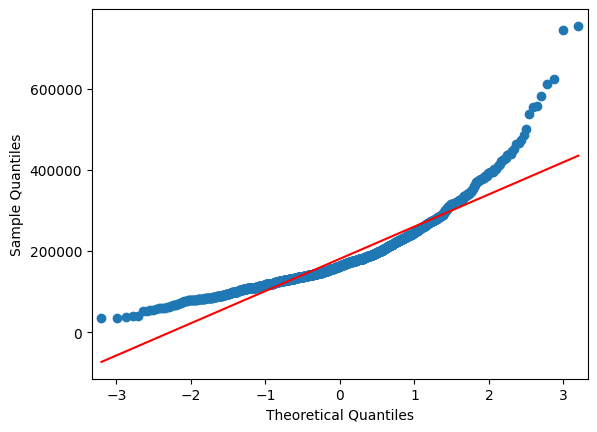

In [10]:
import statsmodels.api as sm
sm.qqplot(train1["SalePrice"], line="s")

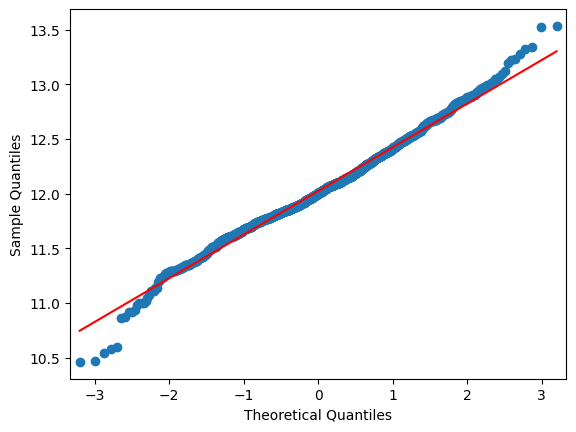

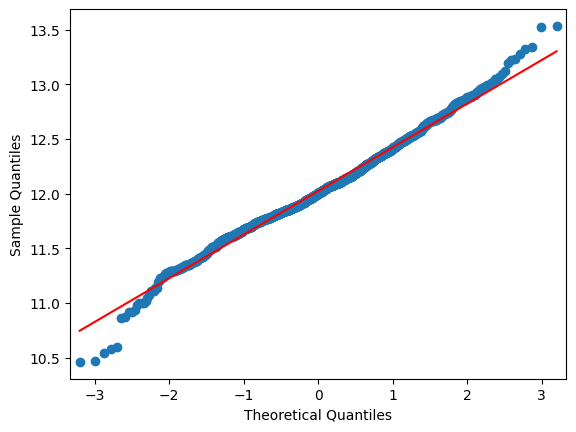

In [11]:
import statsmodels.api as sm
sm.qqplot(np.log(train1["SalePrice"]), line="s")

In [12]:
train1["logPrice"] = np.log(train1["SalePrice"])

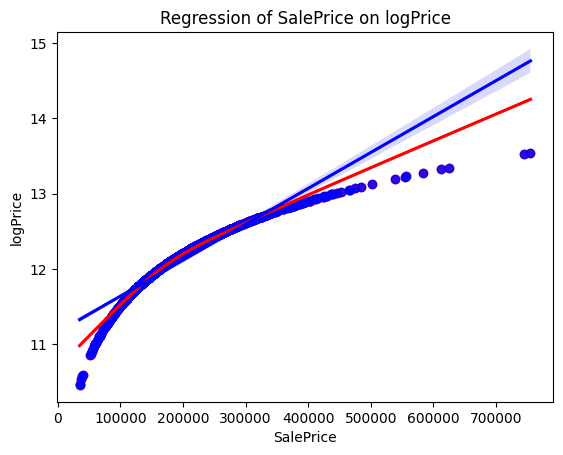

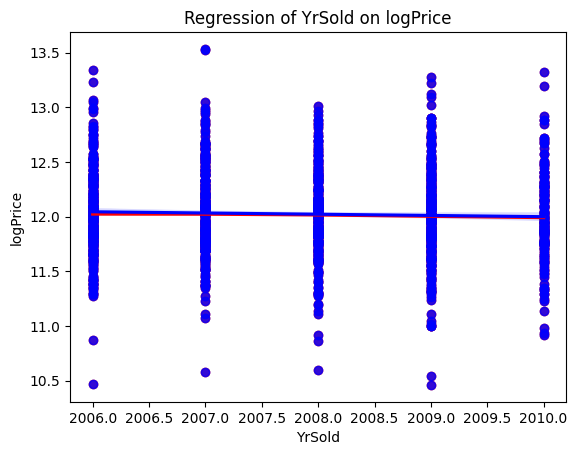

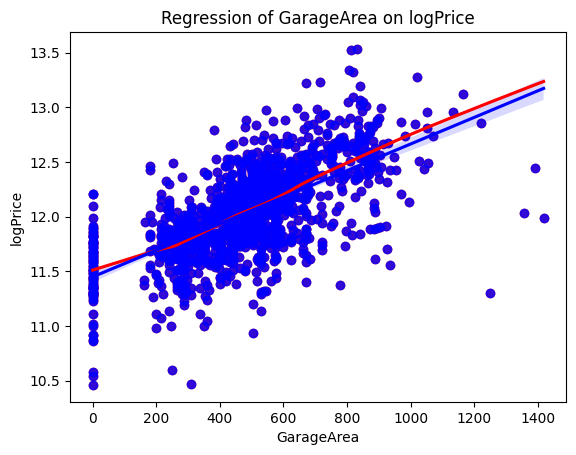

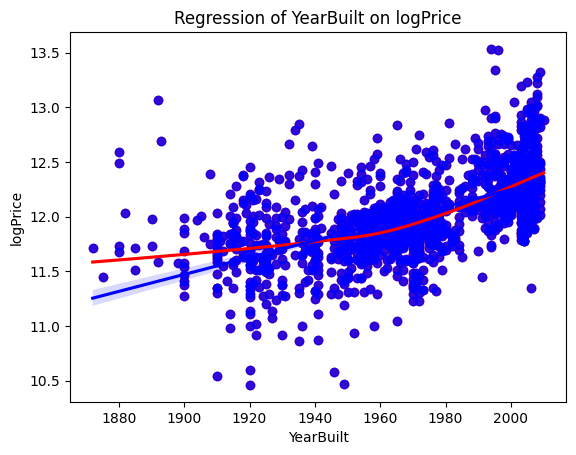

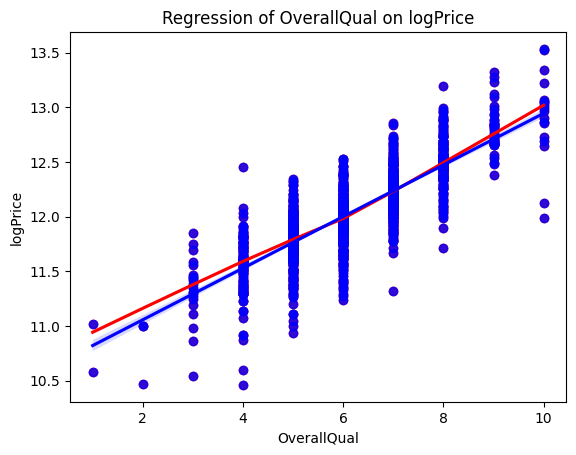

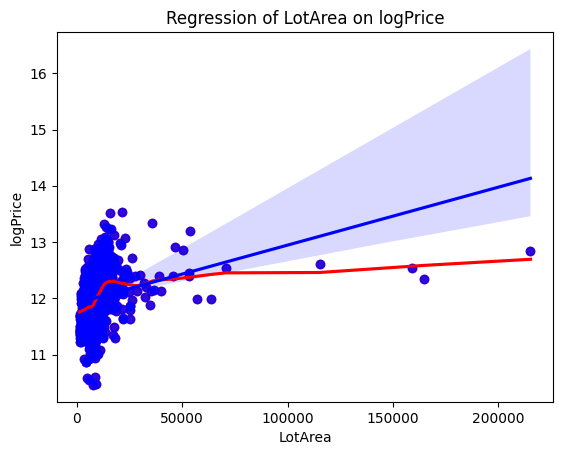

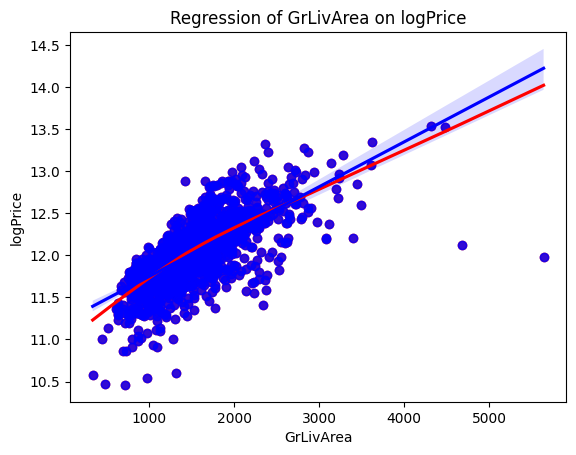

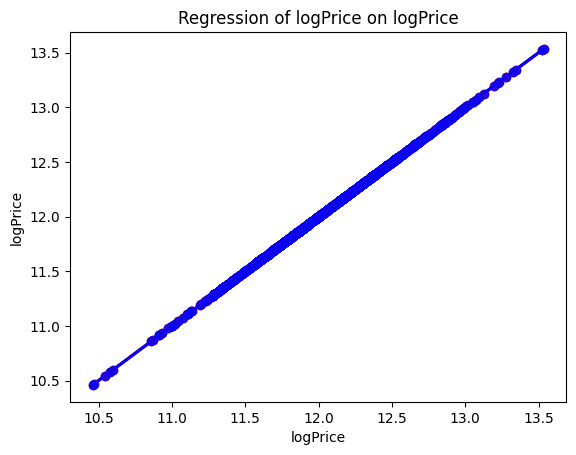

In [13]:
features = train1.drop(train_dummies.columns.to_list(), axis=1).columns.to_list()

for feature in features:
    sns.regplot(x = feature, y="logPrice", data=train1, lowess=True, color="red")
    sns.regplot(x = feature, y="logPrice", data=train1, lowess=False, color="blue")
    plt.title(f"Regression of {feature} on logPrice")
    plt.show()

In [20]:
train1[train1["LotArea"]<=100000]["LotArea"]

0        8450
1        9600
2       11250
3        9550
4       14260
        ...  
1455     7917
1456    13175
1457     9042
1458     9717
1459     9937
Name: LotArea, Length: 1456, dtype: int64

<Axes: xlabel='LotArea', ylabel='logPrice'>

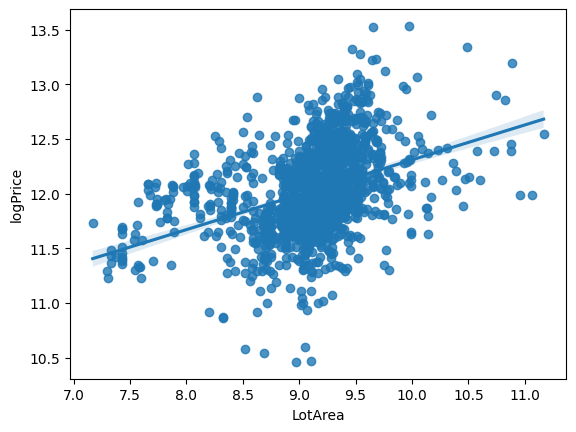

In [23]:
from sympy import lowergamma


sns.regplot(x=np.log(train1[train1["LotArea"]<=100000]["LotArea"]), y=train1[train1["LotArea"]<=100000]["logPrice"])

In [ ]:
# Feature engineering
train1["Year2"] = train1["YearBuilt"]**2
train1["logLotArea"] = np.log(train1["LotArea"])
test1["Year2"] = test1["YearBuilt"]**2
# Attention!!
test1["logLotArea"] = np.log(test1["LotArea"])

In [ ]:
train1 = train1.drop(["SalePrice", "LotArea"], axis=1)
test1 = test1.drop(["LotArea"], axis=1)

KeyError: "['SalePrice'] not found in axis"

In [28]:
# Add constant
from sklearn.model_selection import train_test_split


train1 = sm.add_constant(train1)
test1 = sm.add_constant(test1)

# Split into train_test set
X_train, X_test, y_train, y_test = train_test_split(train1.drop("logPrice", axis=1), train1["logPrice"])

In [32]:
test1 = test1.fillna(test1["GarageArea"].median())

In [41]:
from sklearn.discriminant_analysis import StandardScaler

numerics = ["YrSold", "GarageArea", "YearBuilt", "OverallQual", "logLotArea", "GrLivArea", "Year2"]
scaler = StandardScaler()
X_train[numerics] = scaler.fit_transform(X_train[numerics])
X_test[numerics] = scaler.transform(X_test[numerics])
X_train["Year2"] = X_train["YearBuilt"] ** 2
X_test["YearBuilt"] = X_test["YearBuilt"] ** 2

In [42]:
X_train[["Year2", "YearBuilt"]]

,Year2,YearBuilt
258,0.991729,0.995856
944,0.198422,-0.445446
939,1.099943,-1.048782
89,0.579464,0.761225
1449,0.001868,-0.043222
...,...,...
818,0.000094,-0.009704
829,1.276743,1.129930
386,4.220317,-2.054341
880,1.276743,1.129930


<Axes: >

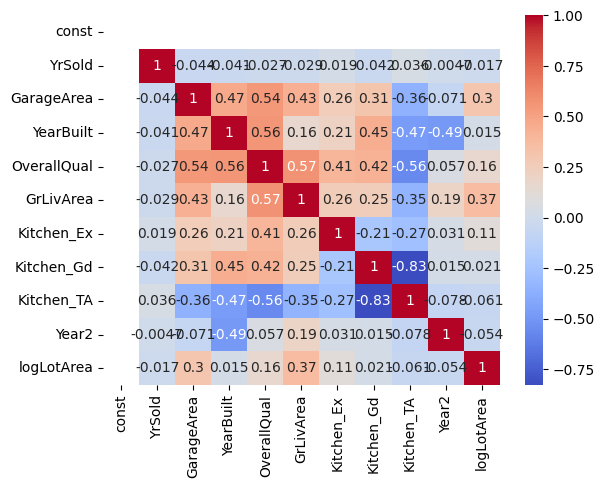

In [43]:
sns.heatmap(X_train.corr(), cmap="coolwarm", annot=True)

In [44]:
# Fit Gamma GLM
Gamma = sm.GLM(y_train, X_train, family=sm.families.Gamma(sm.families.links.Log())).fit()
print(Gamma.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               logPrice   No. Observations:                 1095
Model:                            GLM   Df Residuals:                     1084
Model Family:                   Gamma   Df Model:                           10
Link Function:                    Log   Scale:                      0.00015184
Method:                          IRLS   Log-Likelihood:                 538.68
Date:                Fri, 25 Jul 2025   Deviance:                      0.16598
Time:                        17:41:47   Pearson chi2:                    0.165
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9974
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.4761      0.002   1004.024      

MAE: 0.1766104444720977, MSE: 0.08731023715843442, R2: 0.42409833832963706


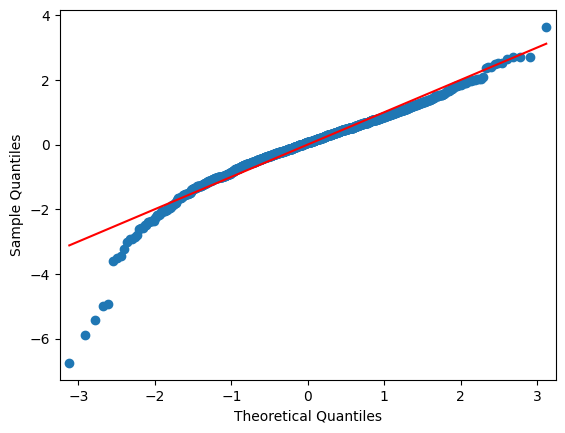

In [50]:
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae, r2_score as r2
# Make test predictions
preds = Gamma.predict(X_test)
print(f"MAE: {mae(preds, y_test)}, MSE: {mse(preds, y_test)}, R2: {r2(preds, y_test)}")

np.exp(mae(preds, y_test))

# Check residual deviance for normality
plt = sm.qqplot(stats.zscore(Gamma.resid_deviance), line="s")

In [63]:
pd.concat([np.exp(preds), np.exp(y_test)], axis=1)

,0,logPrice
135,190552.418696,174000.0
1459,133278.721355,147500.0
1223,183673.610979,137900.0
600,308537.790771,275000.0
524,280853.153817,315750.0
...,...,...
861,135187.463208,131500.0
1322,224501.209890,190000.0
1431,128666.950541,143750.0
1109,279022.831205,280000.0


In [53]:
# TabPFN
TABPFN_ALLOW_CPU_LARGE_DATASET=True
from tabpfn import TabPFNRegressor
tabpfn = TabPFNRegressor(n_estimators=8, ignore_pretraining_limits=True)
tabpfn.fit(X_train, y_train)
tabpfn_preds = tabpfn.predict(X_test)
print(f"TabPFN MAE: {mae(tabpfn_preds, y_test)}, MSE: {mse(tabpfn_preds, y_test)}, R2: {r2(tabpfn_preds, y_test)}")

TabPFN MAE: 0.14857410383584696, MSE: 0.05117317286628372, R2: 0.6267606001723336


In [57]:
train["SalePrice"].loc[0:500]

0      208500
1      181500
2      223500
3      140000
4      250000
        ...  
496    430000
497    184000
498    130000
499    120000
500    113000
Name: SalePrice, Length: 501, dtype: int64